--- 1. SYMBOLIC SETUP & PARTIAL FRACTION EXPANSION ---
Partial fraction expansion of Y(s):


1/(4*(s + 4)) - 1/(4*(s + 2)) + 1/(2*(s + 2)**2)


Expressed in terms of j*omega:


1/(4*(I*omega + 4)) - 1/(4*(I*omega + 2)) + 1/(2*(I*omega + 2)**2)

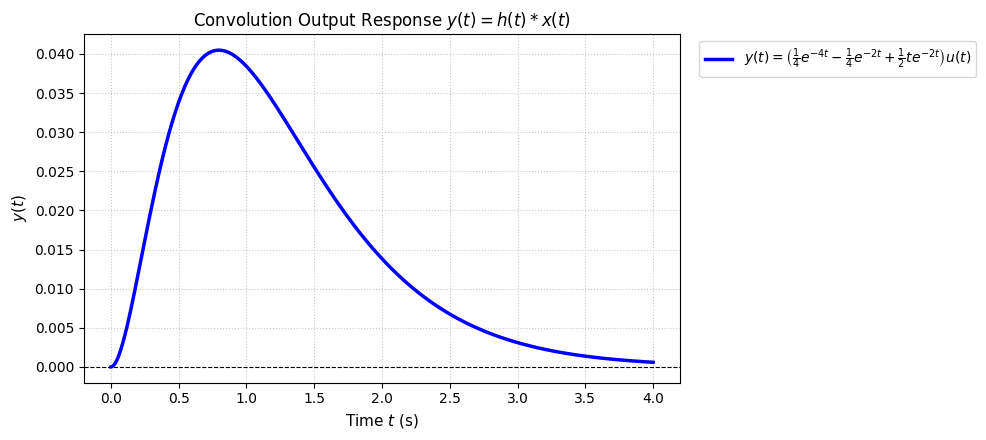

In [2]:
# Notebook: Convolution via Fourier Transform and Partial Fraction Expansion
# Signals: x(t) = t * e^{-2t} * u(t), h(t) = e^{-4t} * u(t)
# Goal: Compute y(t) = h(t) * x(t) using Partial Fraction Expansion

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define real symbols
t, omega = sp.symbols('t omega', real=True)

print("--- 1. SYMBOLIC SETUP & PARTIAL FRACTION EXPANSION ---")
# Define the frequency-domain product Y(j\omega) = X(j\omega) * H(j\omega) = 1 / ((2 + j\omega)^2 * (4 + j\omega))
# Let's use a dummy variable for j*omega to apply sp.apart cleanly
s_dummy = sp.symbols('s', real=True)
Y_expr = 1 / ((2 + s_dummy)**2 * (4 + s_dummy))

# Perform partial fraction expansion
partial_fractions = sp.apart(Y_expr, s_dummy)
print("Partial fraction expansion of Y(s):")
display(partial_fractions)

# Substitute back s_dummy -> j*omega
Y_omega = partial_fractions.subs(s_dummy, sp.I * omega)
print("\nExpressed in terms of j*omega:")
display(Y_omega)


# ==========================================================
# 2. TIME-DOMAIN NUMERICAL VERIFICATION & PLOTTING
# ==========================================================
def plot_convolution_response():
    # Define time vector for t >= 0 (using unit step u(t))
    t_vals = np.linspace(0, 4, 500)
    
    # Analytical expression of y(t) * u(t) derived from the partial fractions and inverse transform:
    # y(t) = (1/4)*e^{-4t} - (1/4)*e^{-2t} + (1/2)*t*e^{-2t}
    y_vals = (1/4) * np.exp(-4 * t_vals) - (1/4) * np.exp(-2 * t_vals) + (1/2) * t_vals * np.exp(-2 * t_vals)
    
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(t_vals, y_vals, 'b-', linewidth=2.5, label=r"$y(t) = \left(\frac{1}{4}e^{-4t} - \frac{1}{4}e^{-2t} + \frac{1}{2}te^{-2t}\right)u(t)$")
    
    ax.set_title(r"Convolution Output Response $y(t) = h(t) * x(t)$", fontsize=12)
    ax.set_xlabel(r"Time $t$ (s)", fontsize=11)
    ax.set_ylabel(r"$y(t)$", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    # Move legend outside to the top right to avoid covering the curves
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute verification plot
plot_convolution_response()